# CNN

## Import Images

In [1]:
import numpy as np
from pathlib import Path
import gzip

%load_ext autoreload
%autoreload 2

# Read info from compressed binary format
BASE_DIR = Path.cwd().parent

# Labels
label_path = BASE_DIR / "MNIST" / 'train-labels-idx1-ubyte.gz'
with gzip.open(label_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_labels = int.from_bytes(f.read(4)) # Number of labels
    labels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of items according to file: {n_labels}")
print(f"actual number of items: {len(labels)}")

# Images
img_path = BASE_DIR / "MNIST" / 'train-images-idx3-ubyte.gz'
with gzip.open(img_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_images = int.from_bytes(f.read(4)) # Number of images
    n_rows = int.from_bytes(f.read(4))
    n_cols = int.from_bytes(f.read(4))
    pixels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of images according to file: {n_labels}")
print(f"n_rows: {n_rows}")
print(f"n_cols: {n_cols}")
print(f"actual number of images: {len(pixels) // (n_rows * n_cols)}")

imgs = pixels.reshape(n_images, n_rows, n_cols)
print(f"number of reshapes images: {len(imgs)}")

number of items according to file: 60000
actual number of items: 60000
number of images according to file: 60000
n_rows: 28
n_cols: 28
actual number of images: 60000
number of reshapes images: 60000


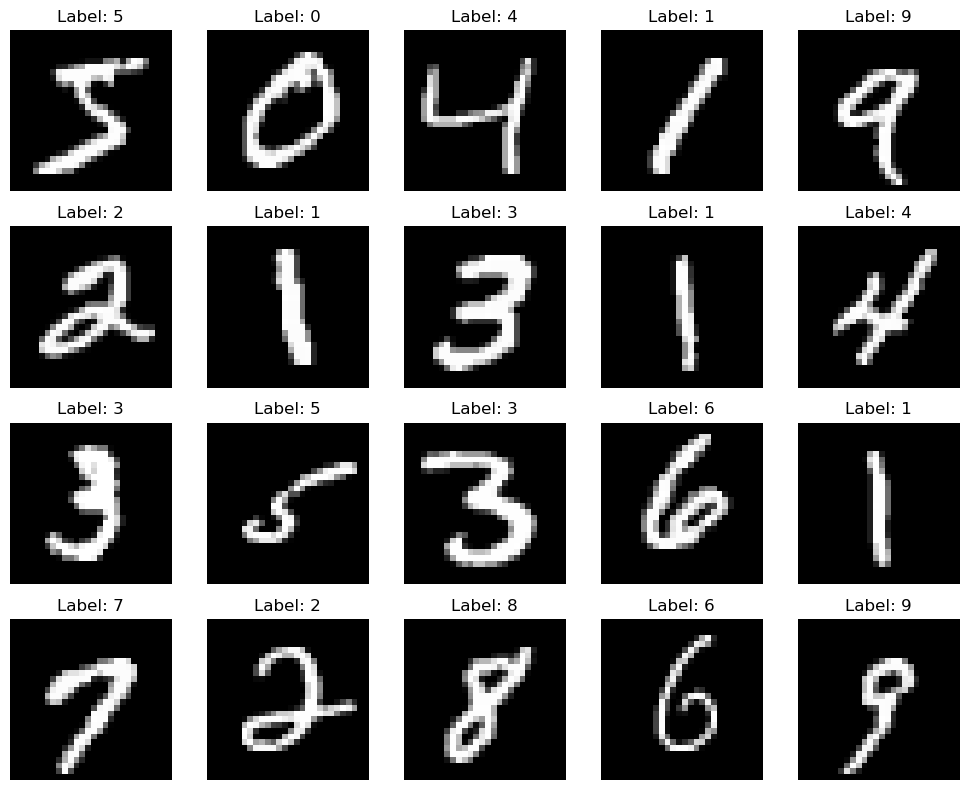

In [2]:
import matplotlib.pyplot as plt

def show_image_grid(imgs, labels, preds=None, ids=range(20), cols=5):
    rows = int(np.ceil(len(ids) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).reshape(-1)

    for ax, id in zip(axes, ids):
        ax.imshow(imgs[id], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Label: {labels[id]}")
        if preds is not None:
            ax.set_title(f"Label: {labels[id]}\nPred: {preds[id]:.3f}")

    for ax in axes[len(ids):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_image_grid(imgs, labels, ids=range(20), cols=5)

In [3]:
indices = np.where(np.isin(labels, [0, 1]))[0]

filtered_imgs = imgs[indices]
print(filtered_imgs.shape)
filtered_labels = labels[indices]

shuffled_indices = np.random.permutation(len(filtered_imgs))
filtered_imgs = filtered_imgs[shuffled_indices]
filtered_labels = filtered_labels[shuffled_indices]

train_size = 8000
val_size = 2000

train_imgs = np.expand_dims(filtered_imgs[:train_size, :, :], axis=1)
train_labels = filtered_labels[:train_size].reshape(-1, 1)
val_imgs = np.expand_dims(filtered_imgs[train_size:train_size+val_size, :, :], axis=1)
val_labels = filtered_labels[train_size:train_size+val_size].reshape(-1, 1)

# Normalization
train_imgs = train_imgs / 255.0
val_imgs = val_imgs / 255.0

print(train_imgs.shape)
print(train_labels.shape)
print(val_imgs.shape)
print(val_labels.shape)

# show_image_grid(filtered_imgs, filtered_labels, ids=range(20), cols=5)

(12665, 28, 28)
(8000, 1, 28, 28)
(8000, 1)
(2000, 1, 28, 28)
(2000, 1)


In [4]:
from NNLibrary.layers import LinearLayer, ConvLayer
from NNLibrary.pools import MaxPool, Flatten
from NNLibrary.activation import Sigmoid
from NNLibrary.loss import BinaryCrossEntropy
from NNLibrary.funcs import total_parameters

BCE = BinaryCrossEntropy()

conv1 = ConvLayer(kernel_size=3, out_channels=3)
sigmoid1 = Sigmoid()
pool1 = MaxPool(size=2, stride=2)
conv2 = ConvLayer(kernel_size=3, in_channels=3, out_channels=3)
sigmoid2 = Sigmoid()
pool2 = MaxPool(size=2, stride=2)
flatten = Flatten()
mlp = LinearLayer(in_dim=75, out_dim=1)
sigmoid3 = Sigmoid()


network = [conv1, sigmoid1, pool1, conv2, sigmoid2, pool2, flatten, mlp, sigmoid3]

n_params = total_parameters(network)


Total parameter count: 190


In [5]:
from NNLibrary.funcs import evaluate, backprop

epochs = 5
lr = 0.1
batch_size = 32

train_losses = []
val_losses = []

for epoch in range(epochs):
    shuffled_train_indices = np.random.permutation(train_size)
    print(epoch)
        
    if epoch % 3 == 0:
        out = evaluate(network, val_imgs)
        val_loss = BCE.forward(out, val_labels)
        val_losses.append(val_loss)
        print(f"Epoch: {epoch} - Val loss {val_loss}")

    for start in range(0, train_size, batch_size):
        end = start + batch_size
        batch_indices = shuffled_train_indices[start:end]

        x_batch = train_imgs[batch_indices]
        y_batch = train_labels[batch_indices]

        out = evaluate(network, x_batch)
        train_loss = BCE.forward(out, y_batch)
        train_losses.append(train_loss)

        backprop(network, BCE, lr) # Backpropagation and weight updates


out = evaluate(network, val_imgs)
val_loss = BCE.forward(out, val_labels)
val_losses.append(val_loss)

0
Epoch: 0 - Val loss 0.6901803069350229
1
2
3
Epoch: 3 - Val loss 0.023566014863021095
4


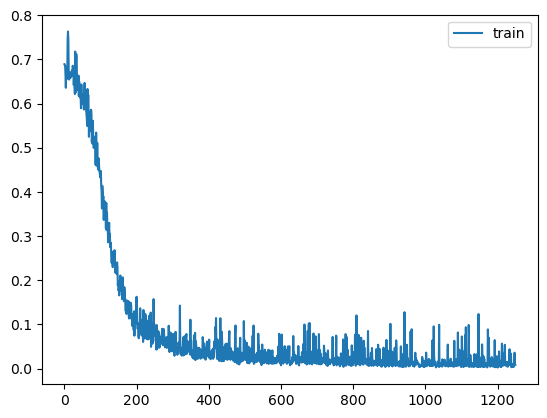

In [6]:
plt.plot(range(len(train_losses)), train_losses, label="train")
# plt.plot(range(epochs)), val_losses, label="val"
plt.legend()
plt.show()

(2000, 1, 28, 28)


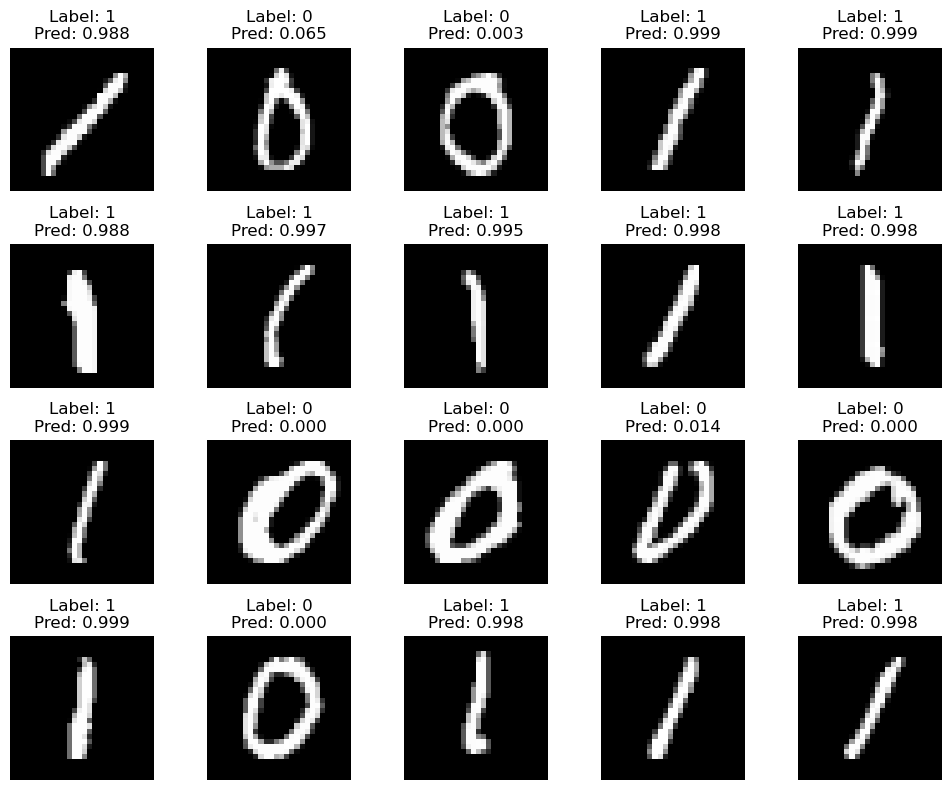

In [7]:
print(val_imgs.shape)

val_img_sample = val_imgs[0:20, :, :, :]
val_label_sample = val_labels[0:20]

val_pred_sample = evaluate(network, val_img_sample)

show_image_grid(val_img_sample.reshape(20, 28, 28), val_label_sample.reshape(20), val_pred_sample.reshape(20), ids=range(20), cols=5)

In [ ]:
# TODO:
# Implement eval / train mode for model - dont want to store vars during eval
# Implement float32 instead of float64

In [10]:
W = np.random.normal(scale=0.01, size=[2, 2, 3])

W.size

12

In [ ]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

x = np.ones([4, 4])

k = np.random.normal(size=[2, 2])

v = sliding_window_view(x, [2, 2])

print(v.shape)


fm = np.dot(v, k)
fm = v * k
print(fm.shape)
fm = np.sum(fm, axis=(-2, -1))
fm.shape


(3, 3, 2, 2)
(3, 3, 2, 2)


(3, 3)

In [7]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

x = np.ones([8, 1, 4, 4])


k = np.random.normal(size=[5, 1, 2, 2]) # out_channel, in_channel, size, size

v = sliding_window_view(x, window_shape=[2, 2], axis=[2, 3])
v = v[:, :, ::2, ::2, :, :]
print(v.shape)

fm = np.amax(v, axis=(4, 5))
print(fm.shape)

# fm = np.transpose(fm, (0, 3, 1, 2))

print(fm.shape)

max_mask = v == fm[:, :, :, :, None, None] # Max mask for backprop

print(max_mask.shape)


(8, 1, 2, 2, 2, 2)
(8, 1, 2, 2)
(8, 1, 2, 2)
(8, 1, 2, 2, 2, 2)


In [8]:
b, k, fm_rows, fm_cols = fm.shape
r_grad = fm

local_grad = np.zeros_like(x, dtype=np.float32)

grad_windows = max_mask * r_grad[:, :, :, :, None, None]

for i in range(fm_rows):
    for j in range(fm_cols):
        row_start = i * 2
        col_start = j * 2
        
        local_grad[:, :, row_start:row_start+2, col_start:col_start+2] += grad_windows[:, :, i, j, : :]

In [10]:
print(grad_windows.shape)

(8, 1, 2, 2, 2, 2)
